In [3]:
import pypsa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from utils import tech_colors

In [2]:
n = pypsa.Network('base_s_1__none_2035_lt.nc')

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


In [288]:
def get_gebote(n, time):

        balance = n.statistics.energy_balance(
                aggregate_time=False,
                nice_names=False,
        ).groupby(['carrier', 'bus_carrier']).sum()

        mask = balance.index.get_level_values("bus_carrier").isin(['AC'])

        balance = balance[mask] # nur AC

        mask = balance.loc[:, time].div(1e2)[lambda s: np.abs(s)>1].index

        carriers = mask.get_level_values("carrier").unique()
        gebot = pd.DataFrame([],index=['marginal_cost'])
        

        for carrier in carriers: 
                if (carrier in n.generators.carrier.unique()):  
                        gebot.loc['marginal_cost', carrier] = n.generators.loc[n.generators.carrier == carrier, "marginal_cost"].mean()
                        gebot.loc['efficiency', carrier] = n.generators.loc[n.generators.carrier == carrier, "efficiency"].mean()
                        gebot.loc['bus0', carrier] =  'none'
                        gebot.loc['bus1', carrier] = 'DE0 0'
                else:
                        #gebot.loc['bus_price', carrier] = n.buses_t.marginal_price[n.links.loc[n.links.carrier == carrier, 'bus0'].iloc[0]].loc[time]
                        gebot.loc['marginal_cost', carrier] = n.links.loc[n.links.carrier == carrier, "marginal_cost"].mean()
                        gebot.loc['efficiency', carrier] = n.links.loc[n.links.carrier == carrier, "efficiency"].mean()
                        sel = n.links.loc[n.links.carrier == carrier, 'bus0']
                        if not sel.empty:
                                gebot.loc['bus0', carrier] = n.links.loc[n.links.carrier == carrier, 'bus0'].iloc[0]
                                gebot.loc['bus1', carrier] = n.links.loc[n.links.carrier == carrier, 'bus1'].iloc[0]
                                gebot.loc['bus_price', carrier] = n.buses_t.marginal_price[n.links.loc[n.links.carrier == carrier, 'bus0'].iloc[0]].loc[time]
                        



        gebot = gebot.fillna(0)

        gebot.loc['market_bid'] = gebot.apply(lambda col: 
                                        ((col['marginal_cost'] + col['bus_price']) / col['efficiency']), axis=0)


        return gebot   


In [289]:
sel =n.links.loc[n.links.carrier == 'electricity', 'bus0']

print(sel.empty)

True


In [290]:
time = '2019-08-07 00:00:00'
get_gebote(n, time)

/var/folders/1l/8dfp16zs2w581ykzgwkyg8nw0000gn/T/ipykernel_8271/3606093760.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'DE0 0 battery' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gebot.loc['bus0', carrier] = n.links.loc[n.links.carrier == carrier, 'bus0'].iloc[0]
/var/folders/1l/8dfp16zs2w581ykzgwkyg8nw0000gn/T/ipykernel_8271/3606093760.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'none' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gebot.loc['bus0', carrier] =  'none'
/var/folders/1l/8dfp16zs2w581ykzgwkyg8nw0000gn/T/ipykernel_8271/3606093760.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'none' has dtype incompatible with float64,

,agriculture electricity,battery discharger,electricity,hydro,industry electricity,offwind-ac,offwind-dc,onwind,ror,rural ground heat pump,urban decentral air heat pump
marginal_cost,0.0,0.015467,0.0,0.0,0.0,0.044406,0.035626,0.045152,0.01037,0.02473,0.023563
efficiency,0.0,0.979796,0.0,0.0,0.0,1.0,1.0,1.0,0.9,1.0,1.0
bus0,0.0,DE0 0 battery,0.0,0.0,0.0,none,none,none,none,DE0 0,DE0 0
bus1,0.0,DE0 0,0.0,0.0,0.0,DE0 0,DE0 0,DE0 0,DE0 0,DE0 0 rural heat,DE0 0 urban decentral heat
bus_price,0.0,118.321786,0.0,0.0,0.0,0,0,0,0,120.771917,120.771917
market_bid,NaN,120.777453,NaN,NaN,NaN,0.044406,0.035626,0.045152,0.011522,120.796647,120.79548


In [354]:
print("battery discharger")

test = pd.DataFrame([], [], dtype=object)




battery discharger


In [360]:



for carrier in ['battery discharger', 'rural ground heat pump']:
    for (name, value) in n.links.loc[n.links.carrier == carrier, 'marginal_cost'].items():
        test.loc['marginal_cost', name] = value    
    for (name, value) in n.links.loc[n.links.carrier == carrier, 'efficiency'].items():
        test.loc['efficiency', name] = value
    for (name, value) in n.links.loc[n.links.carrier == carrier, 'bus0'].items():
        test.loc['bus0', name] = value
        if value != 'DE0 0':
            test.loc['bus_price', name] = n.buses_t.marginal_price[value].loc[time]
    for (name, value) in n.links.loc[n.links.carrier == carrier, 'bus1'].items():
        test.loc['bus1', name] = value
        if value != 'DE0 0':
            test.loc['bus_price', name] = n.buses_t.marginal_price[value].loc[time]
            
    





test

,DE0 0 battery discharger-2035,DE0 0 battery discharger-2030,DE0 0 rural ground heat pump-2035,DE0 0 rural ground heat pump-2030,DE0 0 rural ground heat pump-2025,DE0 0 rural ground heat pump-2019
marginal_cost,0.010039,0.020895,0.010384,0.018918,0.029238,0.04038
efficiency,0.979796,0.979796,1.0,1.0,1.0,1.0
bus0,DE0 0 battery,DE0 0 battery,DE0 0,DE0 0,DE0 0,DE0 0
bus1,DE0 0,DE0 0,DE0 0 rural heat,DE0 0 rural heat,DE0 0 rural heat,DE0 0 rural heat
bus_price,118.321786,118.321786,30.265068,30.265068,30.265068,30.265068


In [189]:
n.buses_t.marginal_price.loc[time, 'DE0 0']

120.77191669956831

# TEST

In [4]:
def plot_balance(nb, ax, tech_colors=None):
    
    resample="D"
    nb = nb.resample(resample).mean()

    df = nb

    # split into df with positive and negative values
    df_neg, df_pos = df.clip(upper=0), df.clip(lower=0)
    df_pos = df_pos[df_pos.sum().sort_values(ascending=False).index]
    df_neg = df_neg[df_neg.sum().sort_values().index]
    # get colors
    c_neg = [tech_colors[col] if col in tech_colors else "grey" for col in df_neg.columns]
    c_pos = [tech_colors[col] if col in tech_colors else "grey" for col in df_pos.columns]


    # plot positive values
    ax = df_pos.plot.area(ax=ax, stacked=True, color=c_pos, linewidth=0.0)

    # rename negative values that are also present on positive side, so that they are not shown and plot negative values
    def f(c):
        return "out_" + c

    cols = [f(c) if (c in df_pos.columns) else c for c in df_neg.columns]
    cols_map = dict(zip(df_neg.columns, cols))
    ax = df_neg.rename(columns=cols_map).plot.area(
        ax=ax, stacked=True, color=c_neg, linewidth=0.0
    )

    # explicitly filter out duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    filtered_handles_labels = [
        (h, l) for h, l in zip(handles, labels) if not l.startswith("out_")
    ]
    handles, labels = zip(*filtered_handles_labels)

    # rescale the y-axis
    ax.set_ylim([1.05 * df_neg.sum(axis=1).min(), 1.05 * df_pos.sum(axis=1).max()])
    

    ax.legend(
        handles,
        labels,
        ncol=1,
        loc="upper center",
        bbox_to_anchor=(1.13, 1.01),
        )
    ax.grid(True)



In [6]:
n = pypsa.Network('base_s_1__none_2035_lt.nc')

INFO:pypsa.io:Imported network base_s_1__none_2035_lt.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


/opt/anaconda3/envs/price-formation/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:1800: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(None, 0)


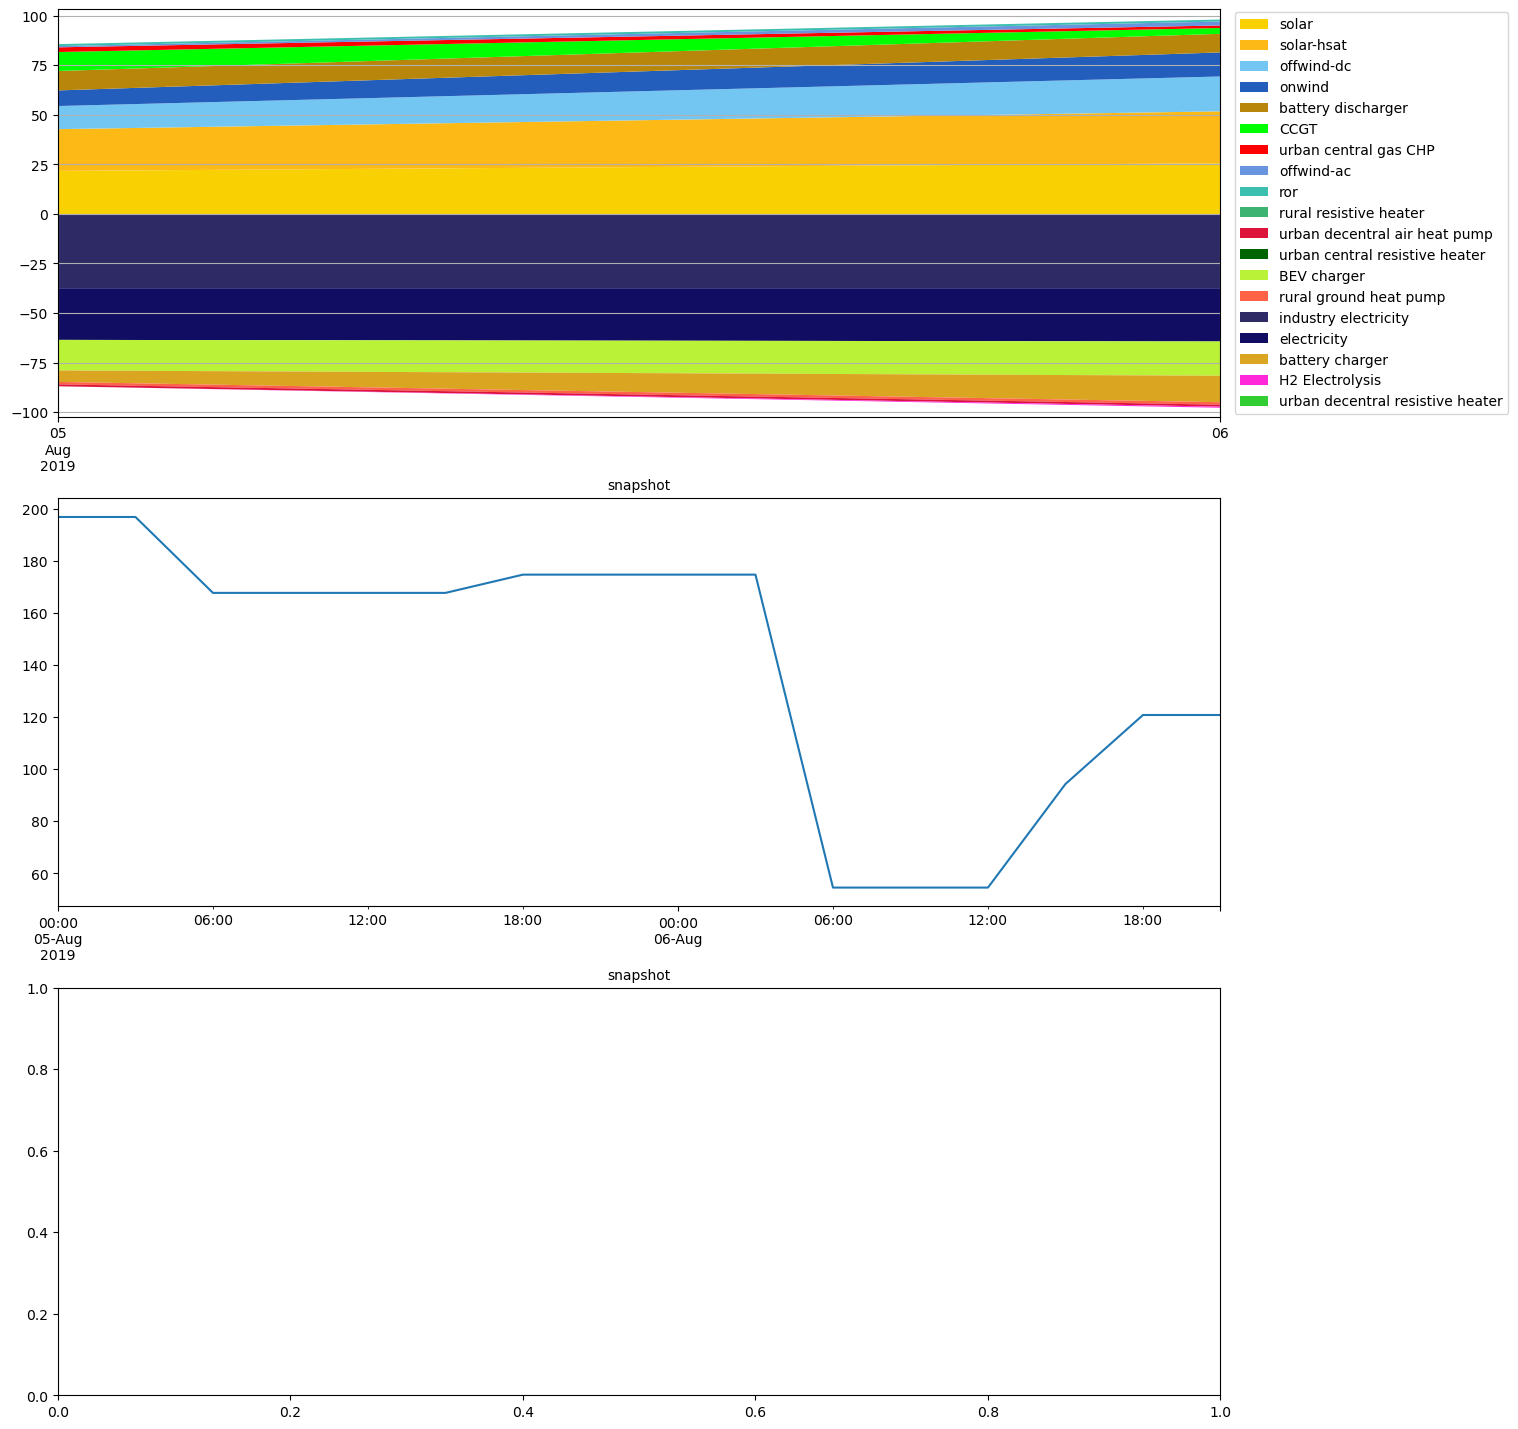

In [13]:
fig, ax = plt.subplots(3,1, figsize=(15,18))
summer = slice('2019-08-05 00:00:00', '2019-08-6 21:00:00')
balance = n.statistics.energy_balance(
    aggregate_time=False,
    nice_names=False,
).groupby(['carrier', 'bus_carrier']).sum()

mask = balance.index.get_level_values("bus_carrier").isin(['AC'])

balance = balance[mask] # nur AC

mask = balance.mean(axis=1).div(1e3)[lambda s: np.abs(s)>1].index
#print(balance)
balance = balance.loc[mask, summer]#.drop(['onwind', 'ror', 'solar', 'offwind-ac', 'offwind-dc', 'solar-hsat', 'electricity', 'BEV charger', 'industry electricity'])
balance = balance.groupby("carrier").sum().div(1e3).T


n.buses_t.marginal_price['DE0 0'].loc[summer].plot(
    label='Network',
    ax=ax[1]
)
    

fig = plot_balance(balance, ax[0], tech_colors)






